У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.ticker import MultipleLocator
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf

In [3]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/data/Store Item Demand Forecasting Challenge/train.csv.zip')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


In [6]:
df.sales.describe()

,sales
count,913000.000000
mean,52.250287
std,28.801144
min,0.000000
25%,30.000000
50%,47.000000
75%,70.000000
max,231.000000


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



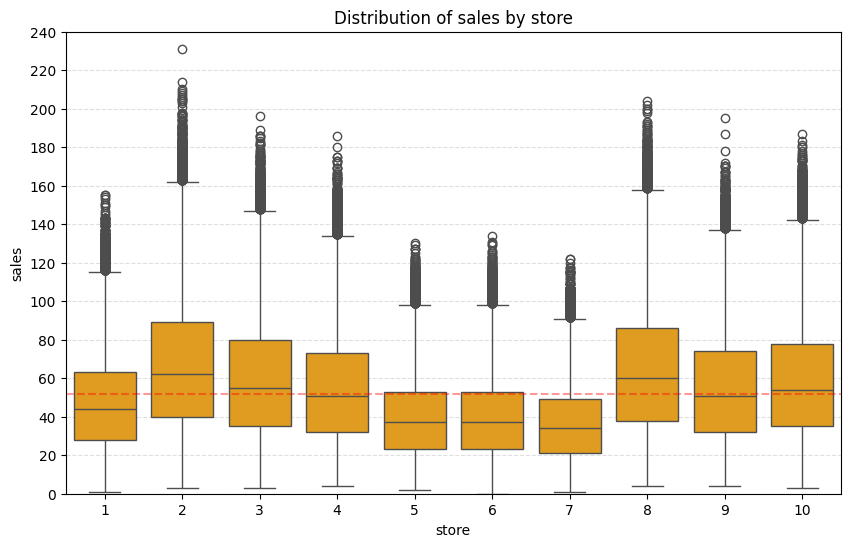

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(df, x='store', y='sales', color='orange')
plt.title("Distribution of sales by store")
ax = plt.gca()
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.yaxis.set_major_locator(MultipleLocator(20))
plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.axhline(y=52, color='red', linestyle='--', alpha=0.4) #sales mean value
plt.ylim(0, 240)
plt.show()

We can see that stores 2, 3, 8 have highest sales, and stores 5, 6, 7 - lowest.   
All stores have outliers data indicationg occasional spikes in sales.

In [8]:
df_mean = df.groupby(by=['store', 'item'])['sales'].mean().unstack()
df_mean.round(2)

item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
store,,,,,,,,,,,,,,,,,,,,,
1,19.97,53.15,33.21,19.96,16.61,53.06,52.78,69.47,46.50,66.35,...,20.00,33.11,46.24,26.59,72.72,52.85,19.81,46.55,26.46,59.34
2,28.17,75.32,46.99,28.23,23.54,74.95,75.06,99.09,65.48,94.10,...,28.07,47.37,65.79,37.79,103.38,75.22,28.19,66.03,37.71,84.62
3,25.07,66.80,41.77,25.12,20.86,67.01,66.65,87.52,58.49,83.39,...,24.99,41.80,58.20,33.39,91.85,66.75,25.12,58.70,33.26,74.96
4,22.94,61.72,38.55,23.09,19.53,61.27,61.63,80.82,54.04,77.05,...,23.17,38.54,54.02,30.95,84.69,61.42,23.11,53.77,30.84,68.92
5,16.74,44.49,27.84,16.78,14.09,44.56,44.54,58.57,38.84,55.51,...,16.83,27.73,39.16,22.42,61.43,44.73,16.70,39.28,22.37,50.32
6,16.72,44.53,27.81,16.75,13.89,44.50,44.60,58.39,39.46,55.57,...,16.61,27.89,39.03,22.32,61.14,44.54,16.71,39.05,22.18,50.52
7,15.16,40.72,25.53,15.36,12.73,40.70,40.71,53.72,35.90,51.16,...,15.47,25.44,35.43,20.45,55.91,40.83,15.48,35.62,20.41,45.82
8,26.98,71.66,45.08,26.95,22.43,71.96,71.73,94.46,63.19,89.82,...,27.04,45.14,62.98,36.19,98.94,72.00,27.15,62.74,36.04,80.97
9,23.33,61.79,38.54,23.15,19.27,61.41,61.81,81.29,54.11,77.11,...,23.19,38.64,54.15,30.97,85.09,62.01,23.00,53.98,31.05,69.31


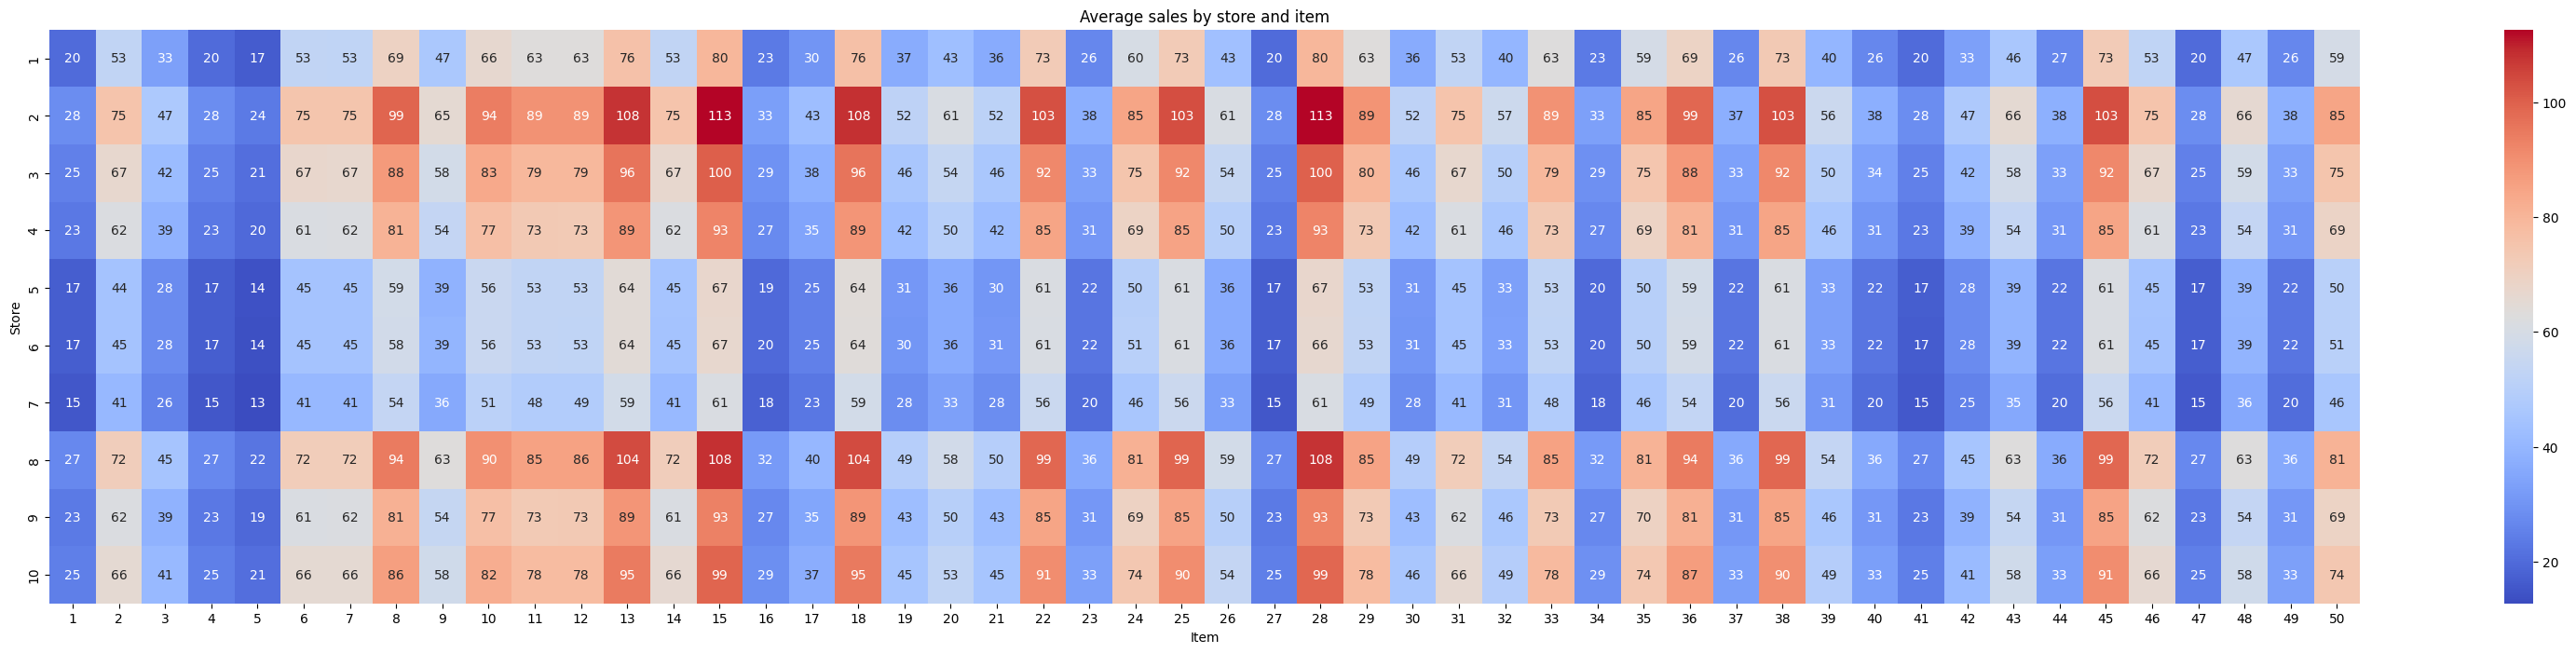

In [9]:
plt.figure(figsize=(40, 8))
ax = sns.heatmap(df_mean, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Average sales by store and item")
plt.xlabel("Item")
plt.ylabel("Store")
plt.show();

Here we also see that stores 2 and 8 have highest sales, but we also see which items are more popular among the stores.  Items 8, 13, 15, 18, 22, 25, 28, 29, 36, 38, 45 are the most popular.

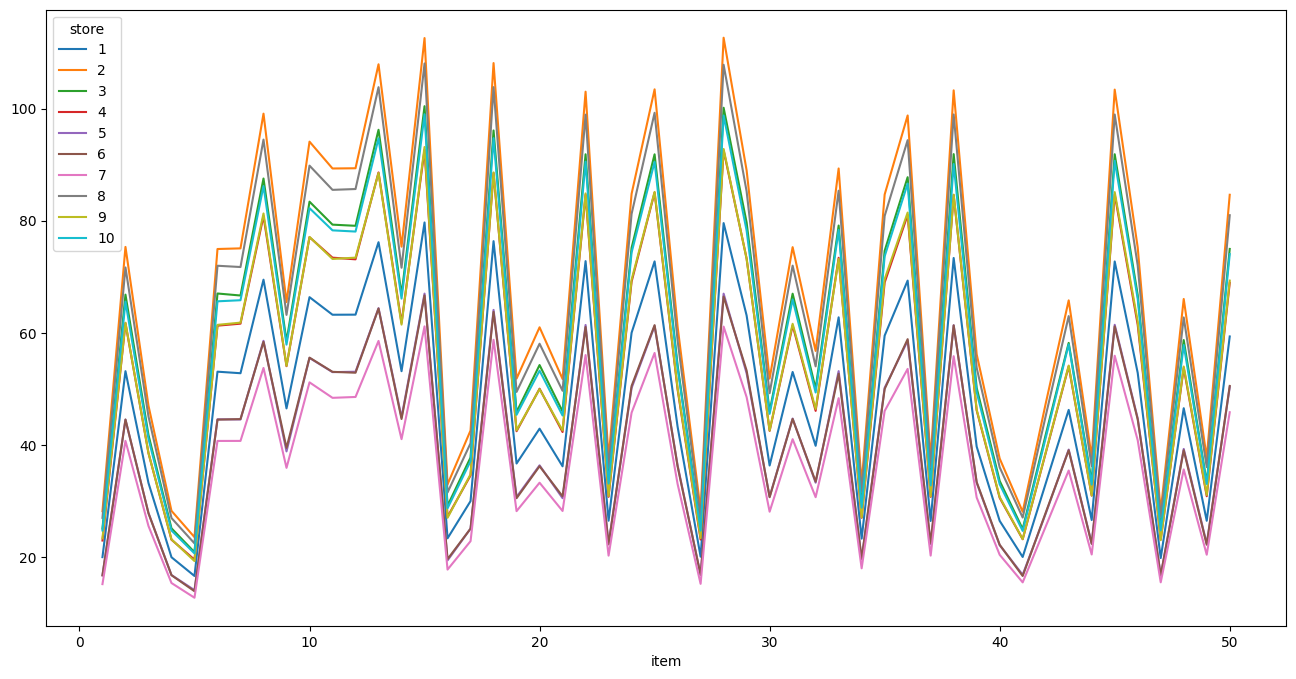

In [10]:
df_mean.T.plot(figsize=(16, 8))
plt.show()

Average sales for each item vary by store.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [11]:
df_one = (df[(df.item == 1) & (df.store == 1)])[['sales']]
df_one.head()

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10


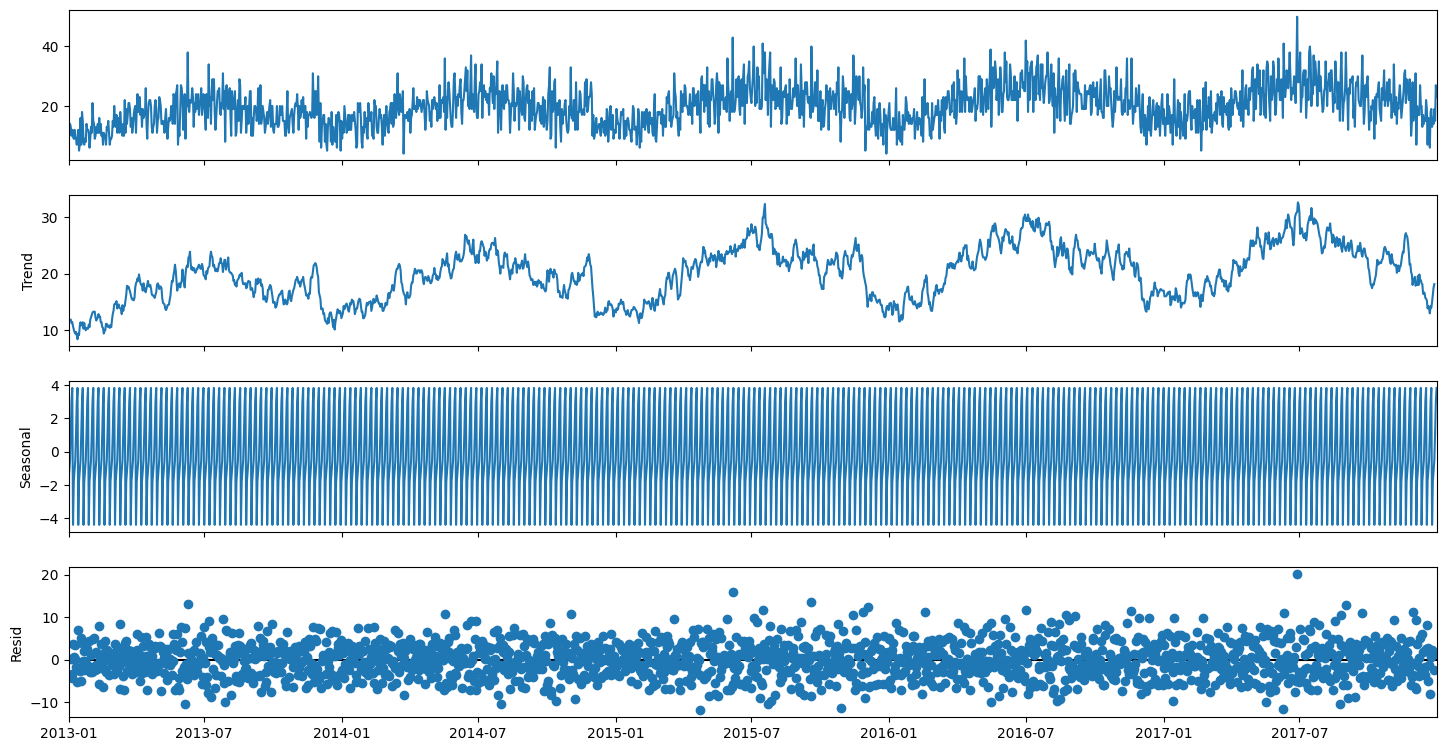

In [12]:
decomposed_additive = seasonal_decompose(df_one, model='additive')
fig = decomposed_additive.plot()
fig.set_size_inches((16, 8))
plt.show()

The data contain both a clear long-term trend and a stable seasonal component.   
The residuals fluctuate around zero but range from -10 to 10, while the actual values range from 0 to 50, indicating that the residuals have relatively hight values.

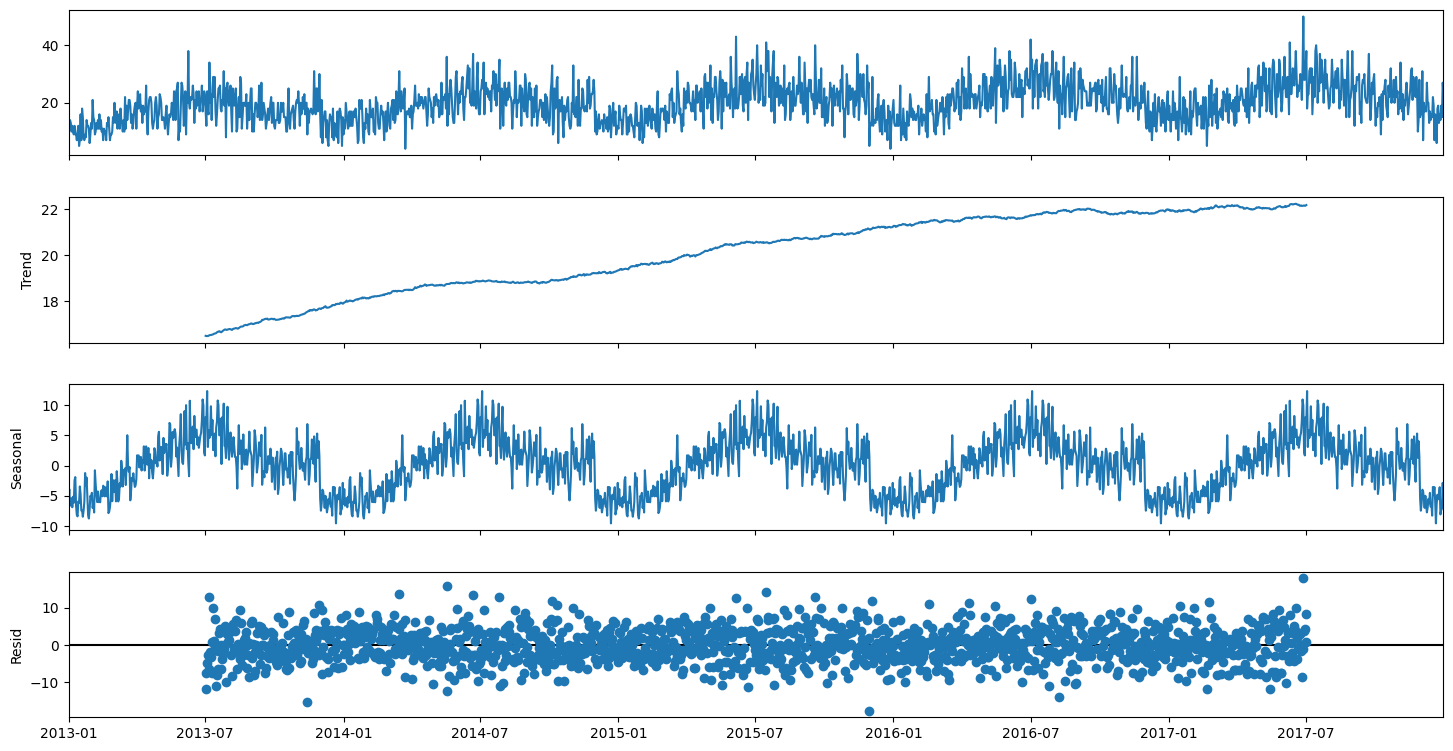

In [13]:
decomposed_additive = seasonal_decompose(df_one, model='additive', period=365)
fig = decomposed_additive.plot()
fig.set_size_inches((16, 8))
plt.show()

Here we observe a clear yearly increasing trend.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [14]:
#!pip install darts --quiet

In [15]:
from darts import TimeSeries
from darts.models import NaiveSeasonal, NaiveDrift, XGBModel, ExponentialSmoothing, ARIMA, AutoARIMA, Prophet, RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.statistics import plot_acf, check_seasonality, plot_hist
from darts.metrics import mape

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import logging
logging.getLogger('cmdstanpy').disabled = True

In [16]:
sales_series = TimeSeries.from_dataframe(df_one, value_cols='sales')
sales_series

<TimeSeries (date: 1826, component: 1, sample: 1)> Size: 15kB
array([[[13.]],

       [[11.]],

       [[14.]],

       ...,

       [[15.]],

       [[27.]],

       [[23.]]])
Coordinates:
  * date       (date) datetime64[ns] 15kB 2013-01-01 2013-01-02 ... 2017-12-31
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

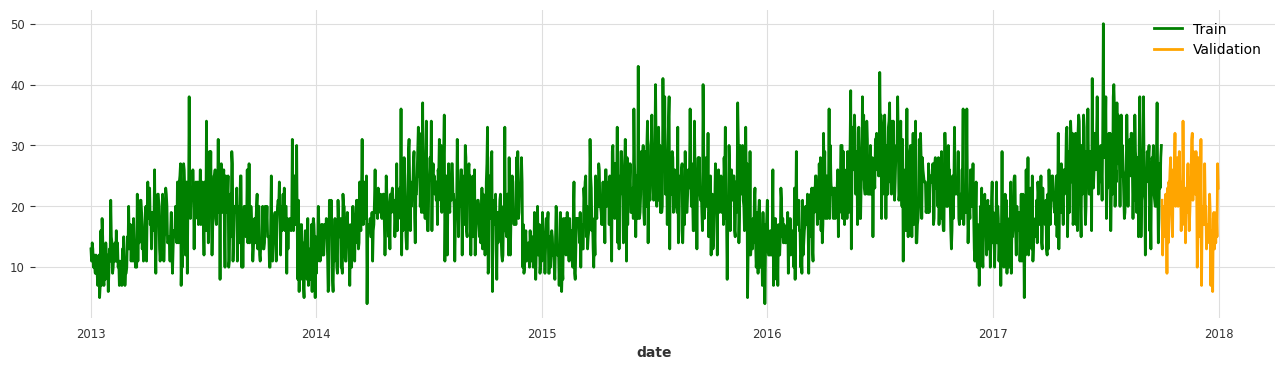

In [17]:
sales_series_train, sales_series_val = sales_series.split_before(pd.Timestamp('2017-10-01'))

plt.figure(figsize=(16, 4))
sales_series_train.plot(color='green', label='Train')
sales_series_val.plot(color='orange', label='Validation')
plt.show()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

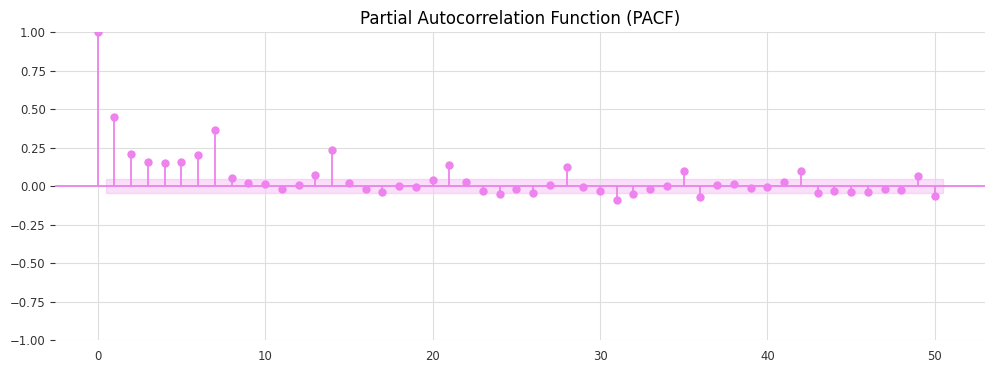

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df_one, lags=50, method='ywm', ax=ax)

for line in ax.lines[::2]:  # horizontal lines
    line.set_color('violet')

for coll in ax.collections: # vertical lines & confidence interval
    coll.set_color('violet')

for line in ax.lines[1::2]: # dots
    line.set_color('violet')

ax.set_title('Partial Autocorrelation Function (PACF)')
plt.show()

Lag 0 has PACF = 1 (as expected — a time series is perfectly correlated with itself at lag 0).   

Lag 1 is strongly positive, indicating strong direct autocorrelation with the immediately previous value.    

Lags 7 and 14 are important highlighting the presence of weekly seasonality.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

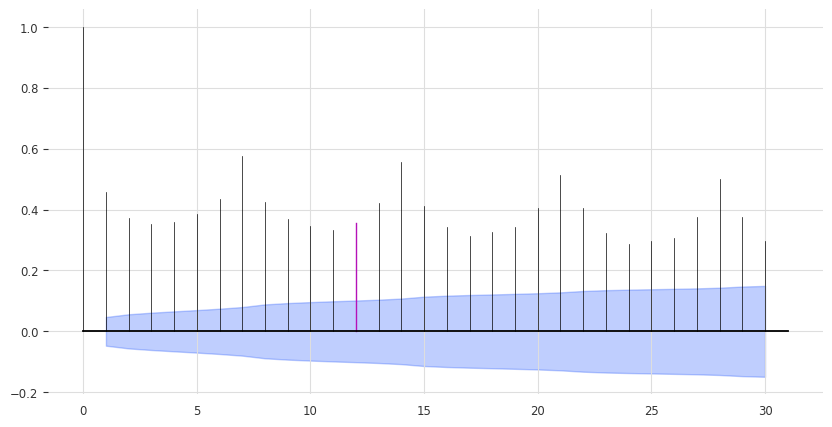

In [19]:
plot_acf(sales_series_train, m=12, alpha=0.05, max_lag=30)

In [20]:
for m in range(2, 30):
    is_seasonal, period = check_seasonality(sales_series_train, m=m, alpha=0.05, max_lag=30)
    if is_seasonal:
        print('There is seasonality of order {}'.format(period))

There is seasonality of order 7
There is seasonality of order 14
There is seasonality of order 21
There is seasonality of order 28


Results shows weekly seasonality.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

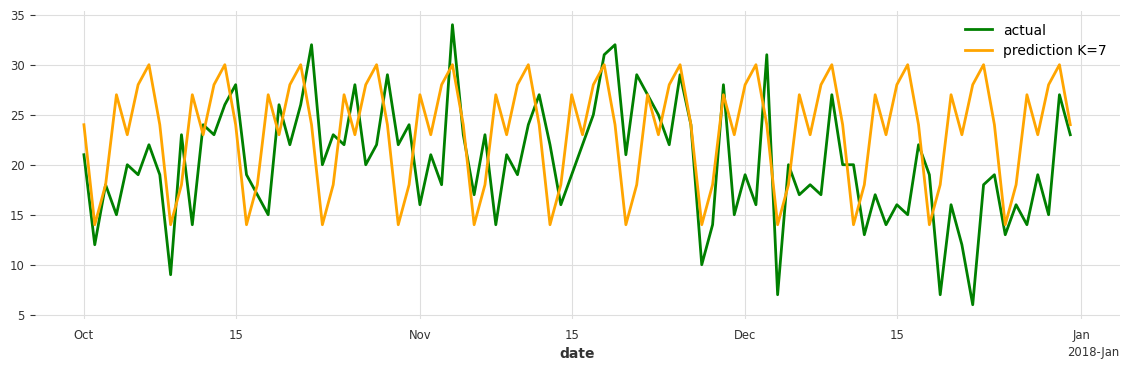

In [21]:
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(sales_series_train)
seasonal_forecast = seasonal_model.predict(len(sales_series_val))

plt.figure(figsize=(14, 4))
sales_series_val.plot(label='actual', color='green')
seasonal_forecast.plot(label='prediction K=7', color='orange')
plt.show();

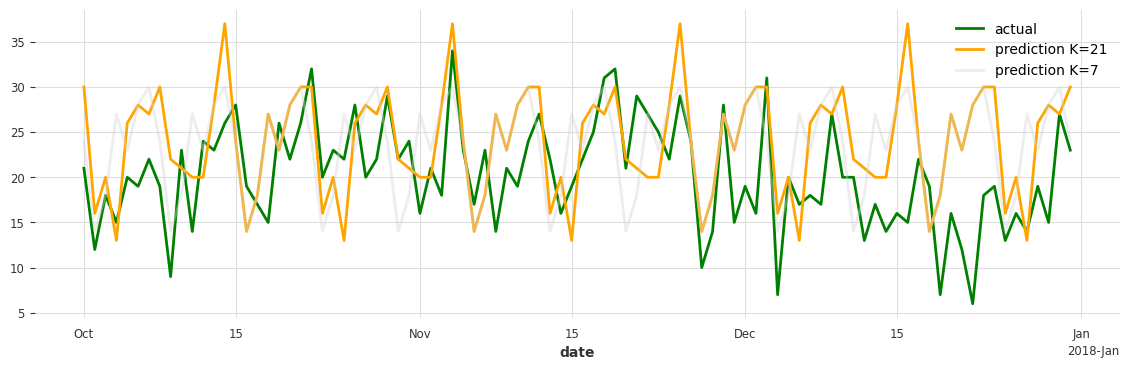

In [22]:
seasonal_model_21 = NaiveSeasonal(K=21)
seasonal_model_21.fit(sales_series_train)
seasonal_forecast_21 = seasonal_model_21.predict(len(sales_series_val))

plt.figure(figsize=(14, 4))
sales_series_val.plot(label='actual', color='green')
seasonal_forecast_21.plot(label='prediction K=21', color='orange')
seasonal_forecast.plot(label='prediction K=7', color='lightgrey', alpha=0.4)
plt.show();

Model with K=21 performs better than with K=7, but it does not consider trend.

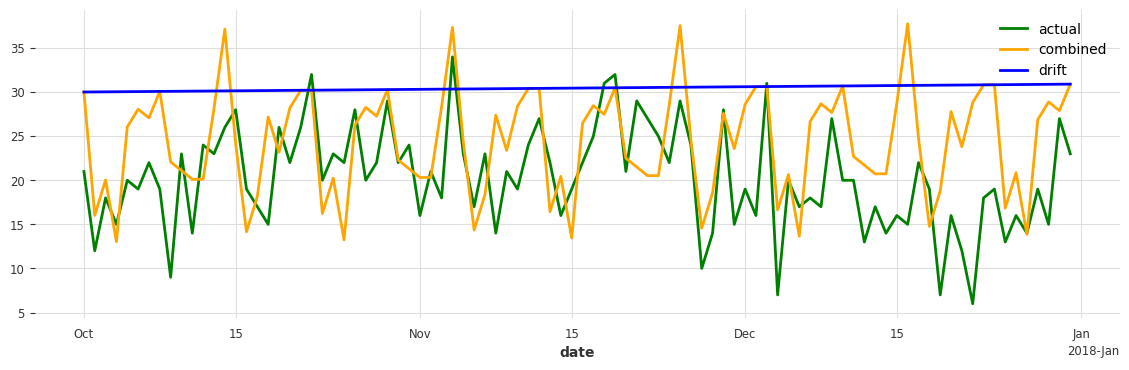

In [23]:
drift_model = NaiveDrift()
drift_model.fit(sales_series_train)
drift_forecast = drift_model.predict(len(sales_series_val))

combined_forecast = drift_forecast + seasonal_forecast_21 - sales_series_train.last_value()

plt.figure(figsize=(14, 4))
sales_series_val.plot(label='actual', color='green')
combined_forecast.plot(label='combined', color='orange')
drift_forecast.plot(label='drift', color='blue')
plt.show();

This model showed good result but still not so accurate, especially for later predictions.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [24]:
print(f'Mean absolute percentage error for the naive seasonal (K=7): {mape(sales_series, seasonal_forecast):.2f}%.')

Mean absolute percentage error for the naive seasonal (K=7): 38.17%.


In [25]:
print(f'Mean absolute percentage error for the naive seasonal (K=21): {mape(sales_series, seasonal_forecast_21):.2f}%.')

Mean absolute percentage error for the naive seasonal (K=21): 37.54%.


In [26]:
print(f'Mean absolute percentage error for the combined naive drift + seasonal: {mape(sales_series, combined_forecast):.2f}%.')

Mean absolute percentage error for the combined naive drift + seasonal: 39.20%.


Seasonal model with K=21 showed best result.

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [27]:
def fit_eval_model(model, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  mape_ = mape(val, forecast)
  print(f"model {str(model).split('(')[0]} MAPE: {mape_:.2f}%")
  print('')

  plt.figure(figsize=(14,4))
  val.plot(label='Actual', color='lightblue')
  forecast.plot(label='Forecast', color='blue')
  plt.legend()
  plt.show()

model XGBRegressor MAPE: 28.92%



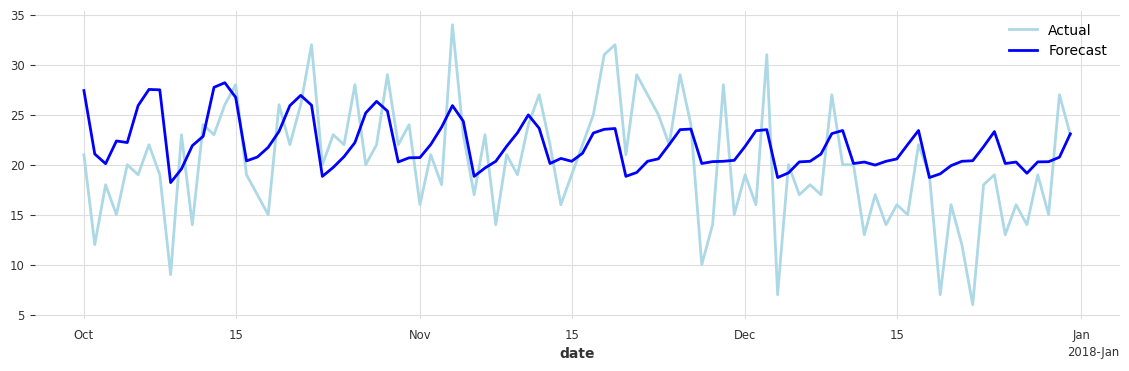

In [28]:
model_xgb = XGBModel(
    lags=21,
    output_chunk_length=1,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.02,
    random_state=42
)

fit_eval_model(model_xgb, sales_series_train, sales_series_val)

Model showed good result but based on graph predictions not accurate.

model obtains MAPE: 27.50%



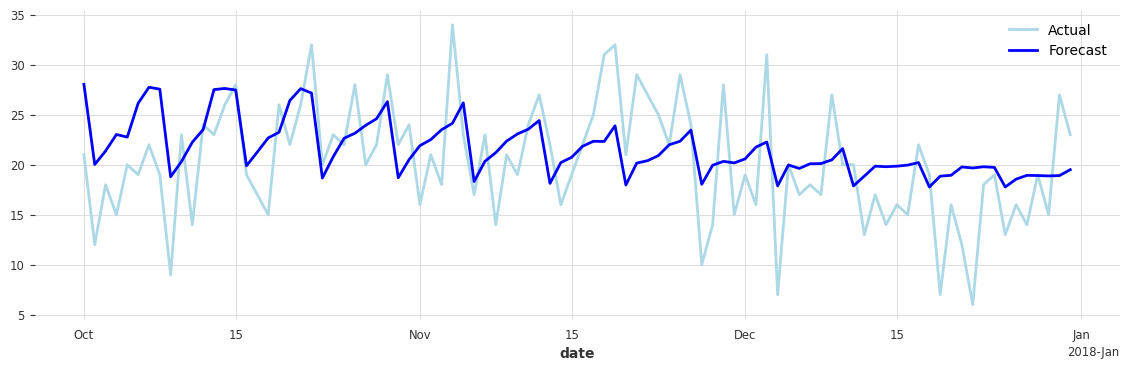

In [29]:
def enrich_with_date_features(df):
  df['day_of_week'] = df['date'].dt.dayofweek
  df['month'] = df['date'].dt.month
  df['quarter'] = df['date'].dt.quarter
  df['year'] = df['date'].dt.year
  df['day_of_year'] = df['date'].dt.dayofyear
  df['day_of_month'] = df['date'].dt.day
  df['sin_day'] = np.sin(df['day_of_year'])
  df['cos_day'] = np.cos(df['day_of_year'])
  df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
  return df

# Додавання ознак дати
train_enriched = enrich_with_date_features(sales_series_train.to_dataframe().reset_index())
val_enriched = enrich_with_date_features(sales_series_val.to_dataframe().reset_index())

# Масштабування даних
scaler = Scaler()
train_transformed = scaler.fit_transform(TimeSeries.from_dataframe(train_enriched, time_col='date'))

model_xgb = XGBModel(
    lags=21,
    output_chunk_length=1,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.02,
    random_state=42
)

model_xgb.fit(train_transformed)
forecast = scaler.inverse_transform(model_xgb.predict(len(sales_series_val)))

mape_ = mape(sales_series_val['sales'], forecast['sales'])
print(f'model obtains MAPE: {mape_:.2f}%')
print('')

plt.figure(figsize=(14,4))
sales_series_val['sales'].plot(label='Actual', color='lightblue')
forecast['sales'].plot(label='Forecast', color='blue')
plt.legend()
plt.show()

Enriching data improved model, but we see that model loose its trend.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

model ExponentialSmoothing MAPE: 39.01%



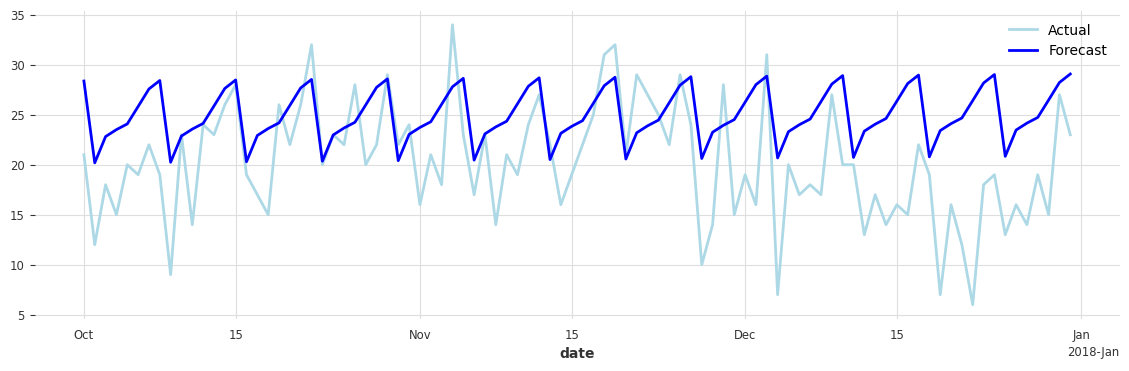

In [30]:
model_exp = ExponentialSmoothing()
fit_eval_model(model_exp, sales_series_train, sales_series_val)

ExponentialSmoothing did not show good results.


12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

model ARIMA MAPE: 39.68%



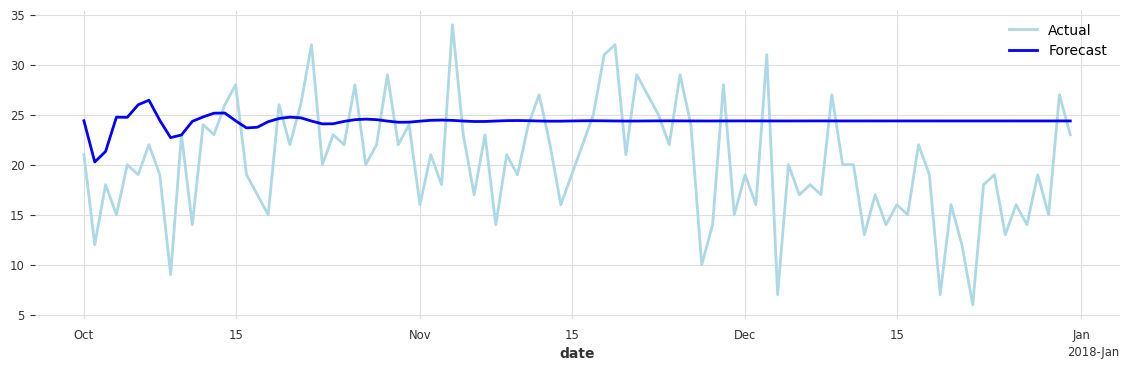

In [31]:
model_arima = ARIMA(p=7, d=1, q=0)
fit_eval_model(model_arima, sales_series_train, sales_series_val)

model ARIMA MAPE: 37.30%



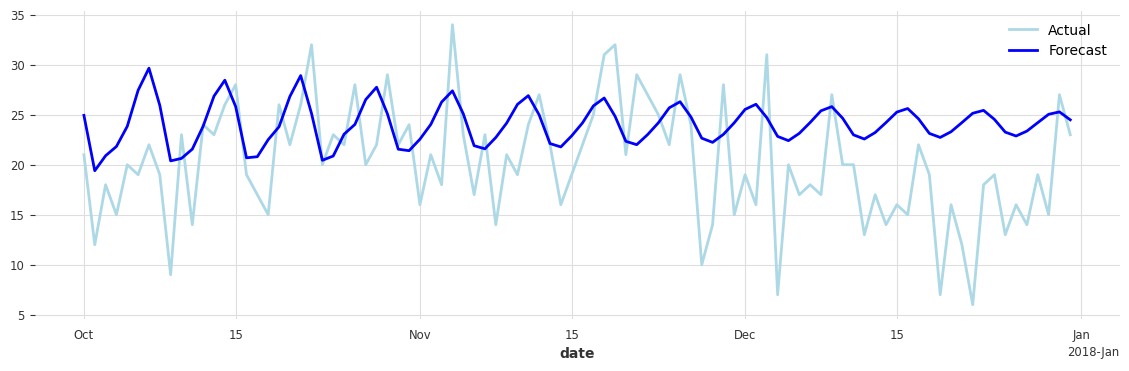

In [32]:
model_arima = ARIMA(p=28, d=1, q=0)
fit_eval_model(model_arima, sales_series_train, sales_series_val)

ARIMA with p=28 performed better than with p=7, and better than ExponentialSmoothing. Predictions don't look accurate on graph.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

model AutoARIMA MAPE: 39.49%



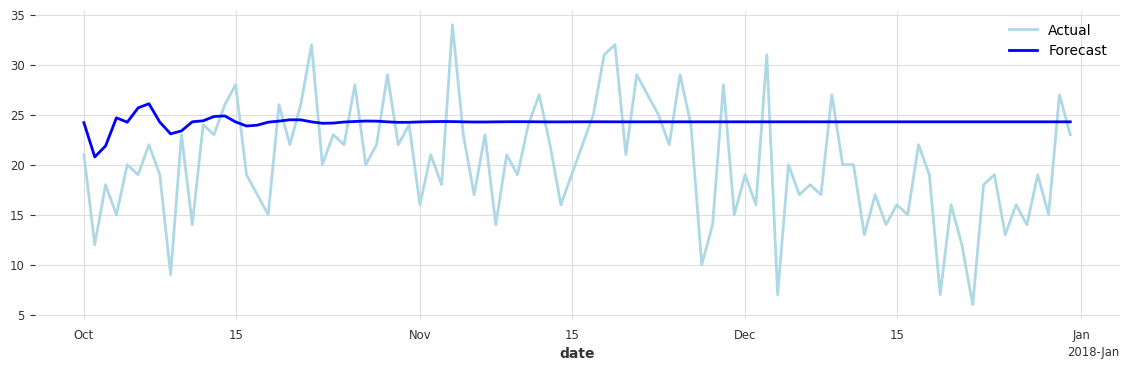

In [33]:
model_auto_arima = AutoARIMA(start_p=7, max_p=28, start_q=1)
fit_eval_model(model_auto_arima, sales_series_train, sales_series_val)

In [34]:
#model_auto_arima.model.summary    this command doesn't work

AutoArima performed worse than an ARIMA model with manual tuned parameters.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


model Prophet MAPE: 23.80%



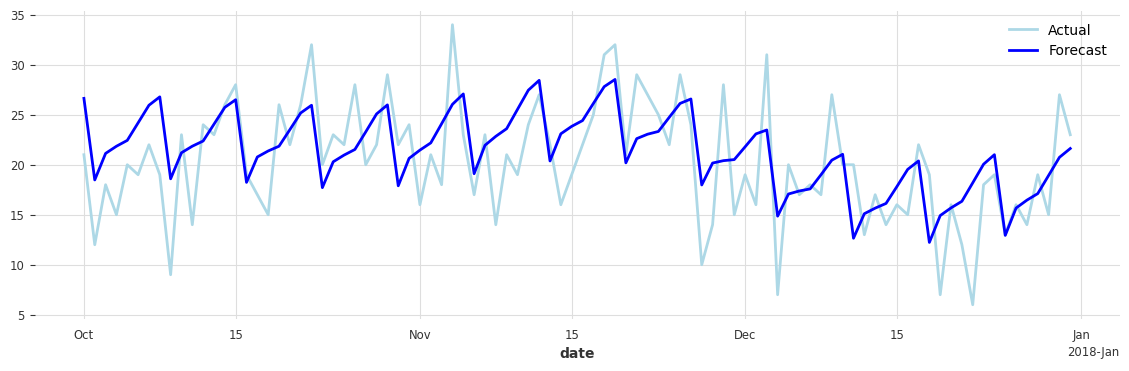

In [35]:
model_prophet = Prophet()
fit_eval_model(model_prophet, sales_series_train, sales_series_val)

So far the best result, also graph looks good.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.023     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=70` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

model RNNModel MAPE: 32.14%



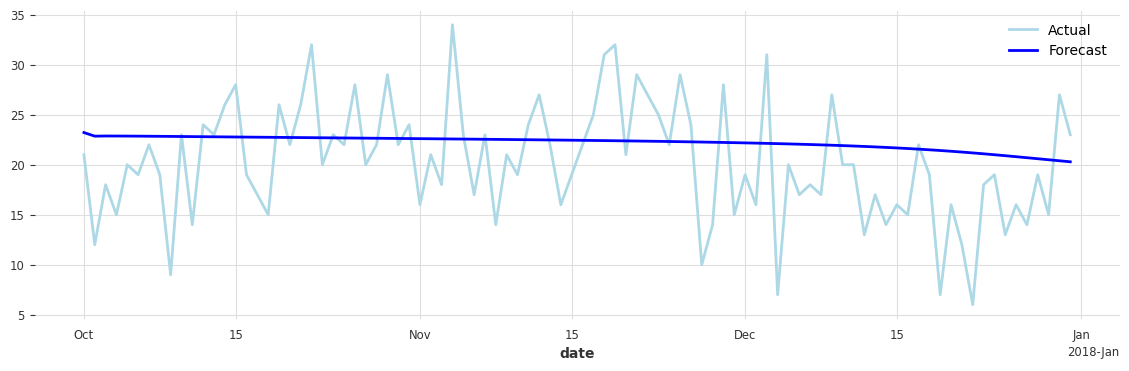

In [36]:
model_rnn = RNNModel(model='LSTM', input_chunk_length=7, n_epochs=70)
fit_eval_model(model_rnn, sales_series_train, sales_series_val)

RNNModel shows good MAPE result, but based on graph predictions are poor.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

`Prophet` model showed best result, lets try to improve it.

In [37]:
add_encoders = {
    'cyclic': {'future': ['day', 'month', 'quarter', 'day_of_week', 'day_of_year']},
    'datetime_attribute': {'future': ['day', 'week', 'month', 'day_of_year', ]},
    'position': {'future': ['relative']},
    'transformer': Scaler(),
}

model_best = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    add_encoders=add_encoders
)

model_best.fit(sales_series_train)
forecast = model_best.predict(len(sales_series_val))
mape_ = mape(sales_series_val, forecast)
print(f'MAPE: {mape_:.2f}%')

MAPE: 22.49%


Lets do backtesting on our best model.

In [38]:
hfc_params = {
    'series': sales_series,
    'start': pd.Timestamp('2017-10-01'),
    'forecast_horizon': 1,
    'verbose': True,
}

historical_fcast = model_best.historical_forecasts(last_points_only=True, **hfc_params)

historical forecasts: 100%|██████████| 92/92 [00:55<00:00,  1.65it/s]


MAPE: 22.14%



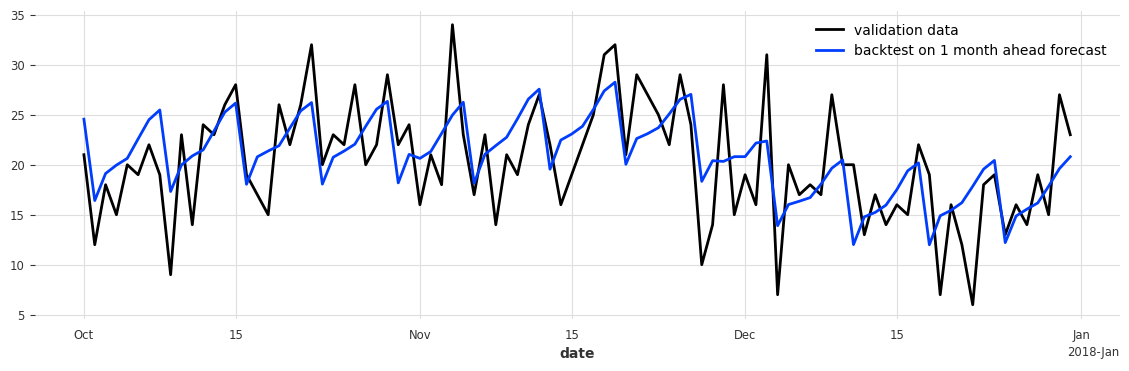

In [39]:
print(f'MAPE: {mape(sales_series, historical_fcast):.2f}%')
print('')

plt.figure(figsize=(14,4))
sales_series_val.plot(label='validation data')
historical_fcast.plot(label='backtest on 1 month ahead forecast')
plt.show()

This is a good result, also not significant difference between Prophet model (`22.49%`) and becktesting (`22.14%`) MAPE

Всю варіантивність не вгадали, але виглядає непогано!

historical forecasts: 100%|██████████| 92/92 [00:54<00:00,  1.69it/s]


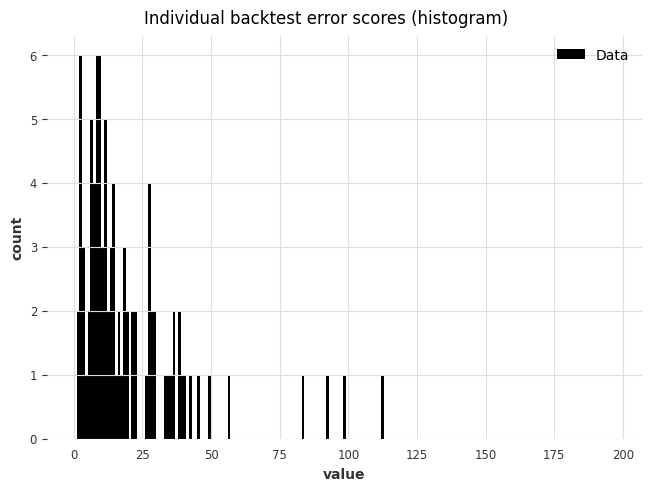

In [40]:
raw_errors = model_best.backtest(metric=mape, reduction=None, last_points_only=False, stride=1, **hfc_params)

plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title='Individual backtest error scores (histogram)',
)

In [41]:
average_error = model_best.backtest(
    metric=mape,
    reduction=np.mean,
    **hfc_params
)

print('')
print(f'Average error (MAPE) over all historical forecasts: {average_error:.2f}')

historical forecasts: 100%|██████████| 92/92 [00:53<00:00,  1.72it/s]


Average error (MAPE) over all historical forecasts: 22.14


INFO:prophet:n_changepoints greater than number of observations. Using 1.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
INFO:prophet:n_changepoints greater than number of observations. Using 4.
INFO:prophet:n_changepoints greater than number of observations. Using 5.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater 

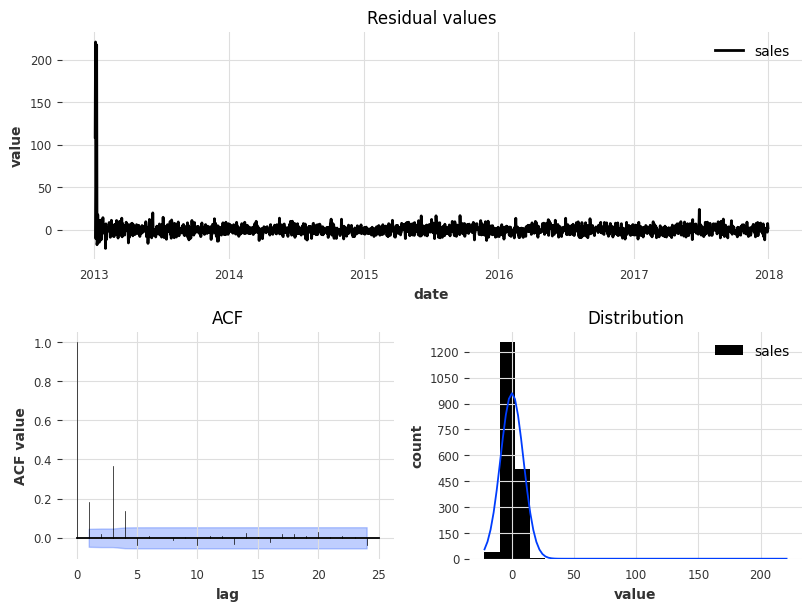

In [42]:
from darts.utils.statistics import plot_residuals_analysis

plot_residuals_analysis(model_best.residuals(sales_series))

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Based on our above research, Prophet model showed best accuracy, but it will be time consuming to train model 50 x 10 times   
We need to use model which can train on many series at once and learn shared patterns.

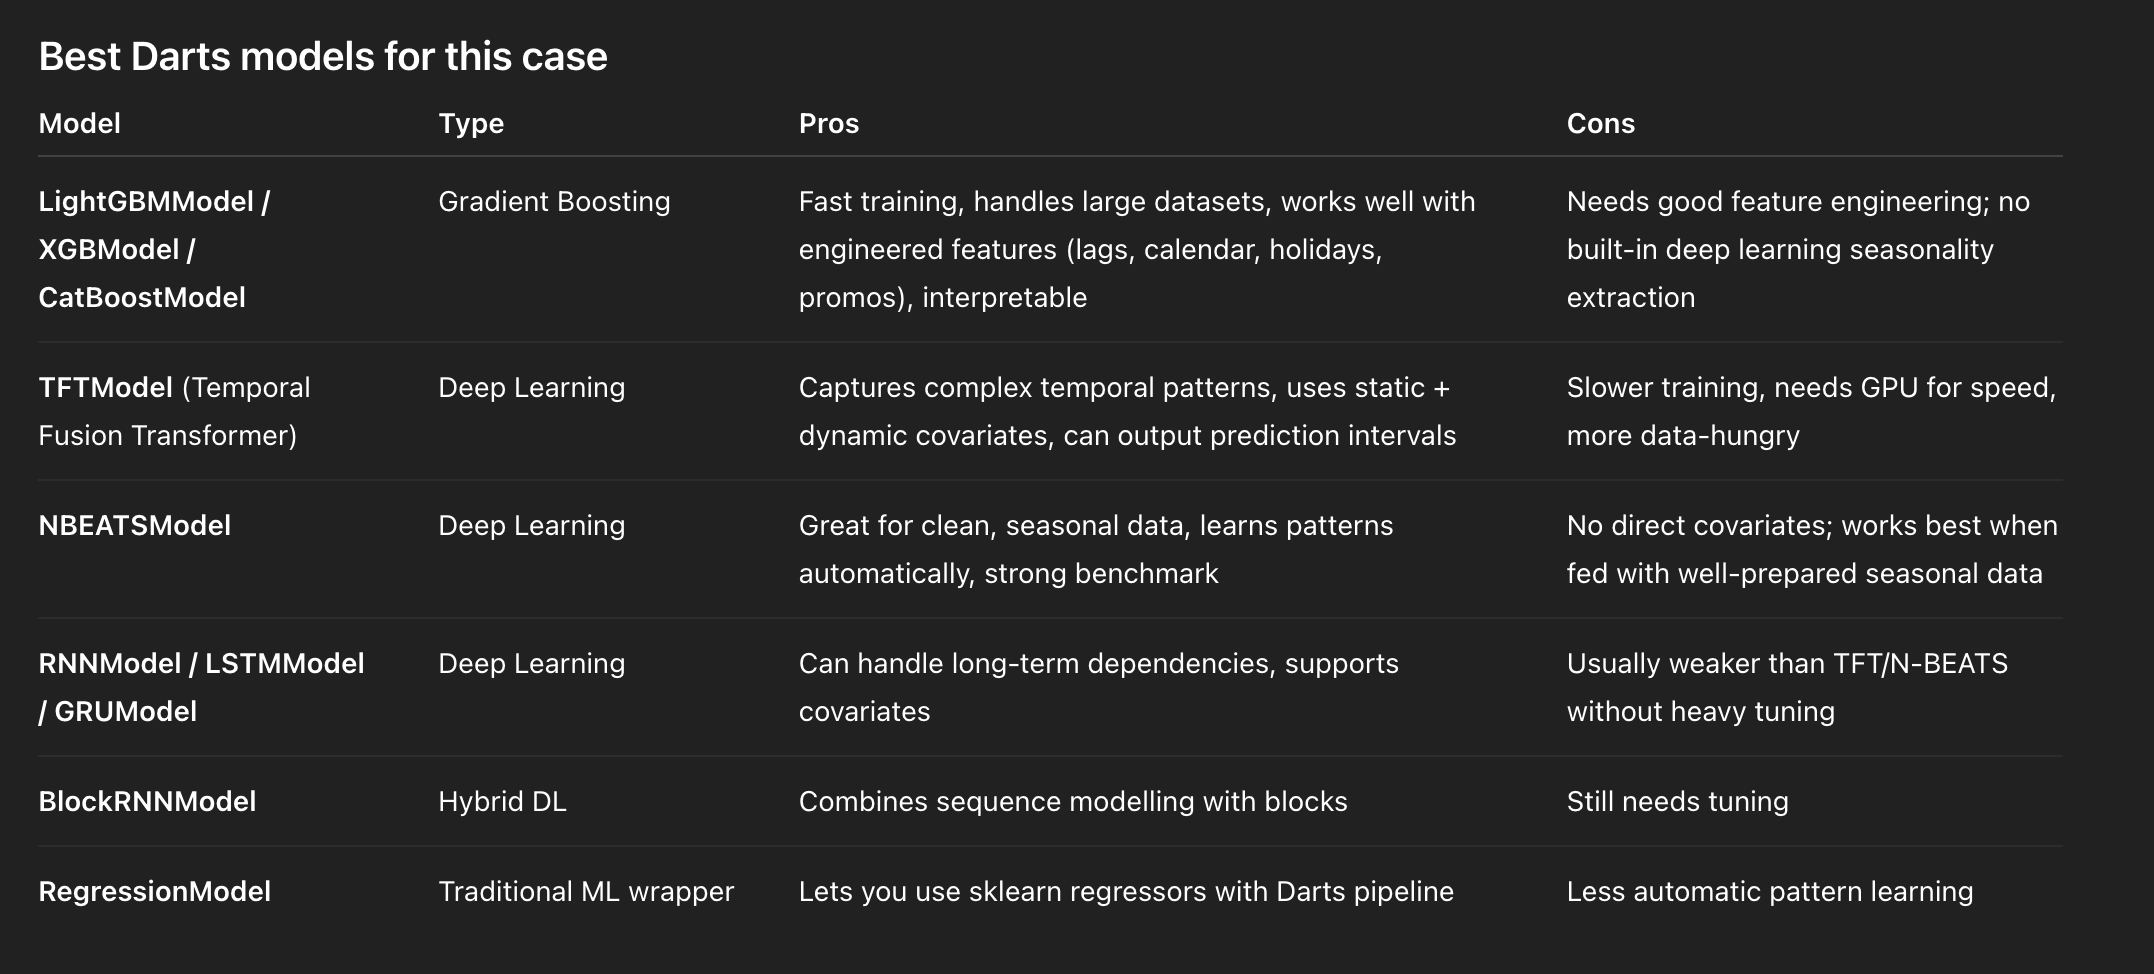

Lets try to use `LightGBMModel` for predictions for all data

In [43]:
from darts.dataprocessing.transformers import MissingValuesFiller
from darts.models import LightGBMModel

In [42]:
series_list = []
filler = MissingValuesFiller("auto")

for (s, i), g in df.groupby(['store','item']):
    ts = TimeSeries.from_dataframe(g, value_cols='sales', fill_missing_dates=True, freq='D')
    ts = filler.transform(ts)
    ts = ts.with_static_covariates(pd.DataFrame({"store_id": [s], "item_id": [i]}))
    series_list.append(ts)

# split
cutoff = pd.Timestamp('2017-10-01')
train_list, val_list = zip(*(ts.split_before(cutoff) for ts in series_list))

# scale target per series
yscaler = Scaler()
train_scaled = [yscaler.fit_transform(ts) for ts in train_list]
val_scaled   = [yscaler.transform(ts)     for ts in val_list]

# model
model = LightGBMModel(
    lags=30,
    lags_future_covariates=[0],
    output_chunk_length=30,
    add_encoders={
        "datetime_attribute": {"future": ["month", "dayofweek"]},
        "cyclic":             {"future": ["month", "dayofweek"]},
        "transformer": Scaler(),
    },
    random_state=42,
)

# fit on all series at once (global model)
model.fit(series=train_scaled)

# predict the first 30 days of validation for each series
pred_scaled_list = model.predict(n=30, series=train_scaled)
pred_list = [yscaler.inverse_transform(p) for p in pred_scaled_list]

# evaluate vs the first 30 days of each val series
def first_n(ts, n=30):
    return ts.slice(ts.start_time(), ts.time_index[min(n-1, len(ts)-1)])

mape_scores = []
for va, pr in zip(val_list, pred_list):
    va_30 = first_n(va, 30)
    pr_30 = first_n(pr, 30)
    # align just in case
    va_30, pr_30 = va_30.slice_intersect(pr_30), pr_30.slice_intersect(va_30)
    if len(va_30) > 0:
        mape_scores.append(mape(va_30, pr_30))

print(f"Mean MAPE over series (30-day horizon): {np.mean(mape_scores):.2f}%")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.171780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7769
[LightGBM] [Info] Number of data points in the train set: 837500, number of used features: 38
[LightGBM] [Info] Start training from score 0.407826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.172720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7769
[LightGBM] [Info] Number of data points in the train set: 837500, number of used features: 38
[LightGBM] [Info] Start training from score 0.408088
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.098153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/v

Mean MAPE over series (30-day horizon): 98.28%


Predictions are not accurate at all.   
What if we take data only from one store.

In [ ]:
df1 = df[df["store"] == 1].copy()
series_list = []
filler = MissingValuesFiller("auto")

for item, g in df1.groupby('item'):
    ts = TimeSeries.from_dataframe(g, value_cols='sales', fill_missing_dates=True, freq='D')
    ts = filler.transform(ts)
    ts = ts.with_static_covariates(pd.DataFrame({"store_id": [1], "item_id": [item]}))
    series_list.append(ts)

# split
cutoff = pd.Timestamp('2017-10-01')
train_list, val_list = zip(*(ts.split_before(cutoff) for ts in series_list))

# scale target per series
yscaler = Scaler()
train_scaled = [yscaler.fit_transform(ts) for ts in train_list]
val_scaled   = [yscaler.transform(ts)     for ts in val_list]

# model
model = LightGBMModel(
    lags=30,
    lags_future_covariates=[0],
    output_chunk_length=30,
    add_encoders={
        "datetime_attribute": {"future": ["month", "dayofweek"]},
        "cyclic":             {"future": ["month", "dayofweek"]},
        "transformer": Scaler(),
    },
    random_state=42,
)

# fit on all series at once (global model)
model.fit(series=train_scaled)

# predict the first 30 days of validation for each series
pred_scaled_list = model.predict(n=30, series=train_scaled)
pred_list = [yscaler.inverse_transform(p) for p in pred_scaled_list]

# evaluate vs the first 30 days of each val series
def first_n(ts, n=30):
    return ts.slice(ts.start_time(), ts.time_index[min(n-1, len(ts)-1)])

mape_scores = []
for va, pr in zip(val_list, pred_list):
    va_30 = first_n(va, 30)
    pr_30 = first_n(pr, 30)
    # align just in case
    va_30, pr_30 = va_30.slice_intersect(pr_30), pr_30.slice_intersect(va_30)
    if len(va_30) > 0:
        mape_scores.append(mape(va_30, pr_30))

In [47]:
print(f"Mean MAPE over series (30-day horizon): {np.mean(mape_scores):.2f}%")

Mean MAPE over series (30-day horizon): 64.13%
